In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
from dataset import SuctionGraspingDataset, data_transform
from model import RGBDResNet101
from eval import evaluate_model

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
model = RGBDResNet101(num_classes=1, pretrained=True)
model = model.to(device).eval()

In [ ]:
data_path = Path("../data")
test_dataset = SuctionGraspingDataset(
    data_path=data_path,
    sample_list=data_path / "test-split.txt",
    transform=data_transform,
)
train_dataset = SuctionGraspingDataset(
    data_path=data_path,
    sample_list=data_path / "train-split.txt",
    transform=data_transform,
)

In [ ]:
snapshot_iterations = [int(file.split("-")[1][:-3]) for file in os.listdir("snapshots")]
snapshot_iterations.sort()

In [9]:
def add_prefix(dictionary, prefix):
    return {prefix + key: value for (key, value) in dictionary.items()}

In [ ]:
results = []

model = RGBDResNet101(num_classes=1, pretrained=True).to(device).eval()

model_results = {"iter_num": 0}
train_results = evaluate_model(model, train_dataset, device)
print("Train:", train_results)
model_results.update(add_prefix(train_results, "train_"))
test_results = evaluate_model(model, test_dataset, device)
print("Test:", test_results)
model_results.update(add_prefix(test_results, "test_"))
results.append(model_results)

In [ ]:
for iter_num in snapshot_iterations:
    print("Evaluating iteration", iter_num)

    checkpoint = torch.load(
        f"snapshots/snapshot-{iter_num}.pt", map_location=device, weights_only=True
    )
    model.load_state_dict(checkpoint["model"])
    model = model.to(device).eval()

    model_results = {"iter_num": iter_num}
    train_results = evaluate_model(model, train_dataset, device)
    print("Train:", train_results)
    model_results.update(add_prefix(train_results, "train_"))
    test_results = evaluate_model(model, test_dataset, device)
    print("Test:", test_results)
    model_results.update(add_prefix(test_results, "test_"))
    results.append(model_results)

Evaluating iteration 1000


  0%|          | 0/368 [00:00<?, ?it/s]

Train: {'bce_loss': 0.19523739607966675, 'mse': 0.058719016021104894, 'precision': 0.9802319451765946}


  0%|          | 0/92 [00:00<?, ?it/s]

Train: {'bce_loss': 0.22600865083916635, 'mse': 0.06884600986455051, 'precision': 0.9619535887749595}
Evaluating iteration 2000


...

Train: {'bce_loss': 0.3366216521821815, 'mse': 0.06909940198916506, 'precision': 0.9711165653621728}
Evaluating iteration 12000


  0%|          | 0/368 [00:00<?, ?it/s]

Train: {'bce_loss': 0.03212368213603286, 'mse': 0.00924199994297684, 'precision': 0.9999089681857241}


  0%|          | 0/92 [00:00<?, ?it/s]

Train: {'bce_loss': 0.35646453300841174, 'mse': 0.07014157363195835, 'precision': 0.9699540227213745}


In [ ]:
df = pd.DataFrame(results).set_index("iter_num").sort_index()
df

,train_bce_loss,train_mse,train_precision,test_bce_loss,test_mse,test_precision
iter_num,,,,,,
0,0.603253,0.205696,0.053405,0.603882,0.205971,0.094444
1000,0.195237,0.058719,0.980232,0.226009,0.068846,0.961954
2000,0.166179,0.049646,0.994198,0.227591,0.067995,0.976018
3000,0.139841,0.041615,0.998561,0.227040,0.068301,0.961911
4000,0.100299,0.029109,0.999887,0.249420,0.067681,0.969212
5000,0.077404,0.022402,0.999972,0.234235,0.065004,0.957237
6000,0.062448,0.018318,0.999857,0.293807,0.069851,0.987076
7000,0.055590,0.016290,0.999946,0.279903,0.067938,0.994439
8000,0.049618,0.014485,0.999895,0.291405,0.068810,0.991016


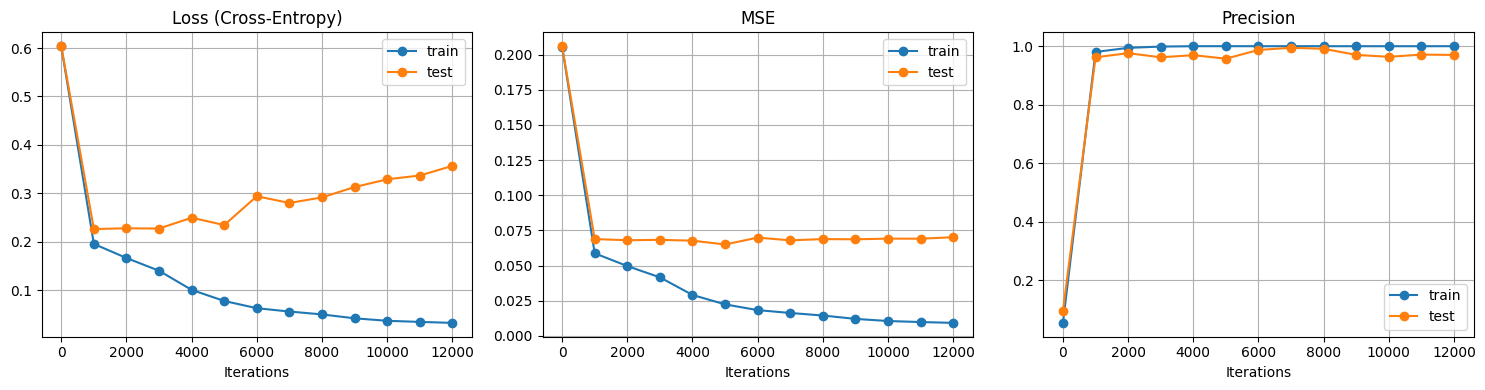

In [ ]:
plots = [
    ("train_bce_loss", "test_bce_loss", "Loss (Cross-Entropy)"),
    ("train_mse", "test_mse", "MSE"),
    ("train_precision", "test_precision", "Precision"),
]

fig, axes = plt.subplots(
    1, len(plots), figsize=(5 * len(plots), 4), sharex=True, sharey=False
)

for ax, (train_col, test_col, title) in zip(axes, plots):
    ax.plot(df.index, df[train_col], label="train", marker="o")
    ax.plot(df.index, df[test_col], label="test", marker="o")
    ax.set_title(title)
    ax.set_xlabel("Iterations")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()